# Market Basket Analysis Using Apriori Principle and FP-Growth Algorithm

## Objective
- To perform data mining for market basket analysis using apriori and FP-growth algorithm

## About Dataset
The Groceries Market Basket Dataset contains 9835 transactions by customers shopping for groceries. The data contains 169 unique items.
The data is suitable to do data mining for market basket analysis which has multiple variables.

## Frequent Pattern Mining
Frequent pattern mining is a data mining technique used to discover patterns, associations, or correlations among items in large datasets.
A very common use case is market basket analysis, where each transaction is a “basket” of items (e.g., products bought together in a grocery store).

Goal:
Find itemsets (combinations of items) that occur frequently together in the transactions, and then derive association rules such as:

If a customer buys X, they are likely to also buy Y.

These patterns can be used for:

- Product placement and store layout
- Cross-selling and recommendation systems
- Understanding customer behavior
- Designing promotions and bundles

Two classic algorithms for frequent pattern mining are Apriori and FP-Growth.

## Apriori Algorithm
Apriori is one of the earliest and most well-known algorithms for mining frequent itemsets.

### Basic Idea
Apriori works in a bottom-up (level-wise) manner:

1. Find all frequent 1-itemsets (single items whose frequency ≥ minimum support).
2. Use these to generate candidate 2-itemsets, then count their frequency and keep only those that are frequent.
3. Use frequent 2-itemsets to generate candidate 3-itemsets, and so on.
4. Stop when no more frequent itemsets can be found.

It uses the Apriori principle:

> If an itemset is frequent, then all of its subsets must also be frequent.
>
> Conversely, if an itemset is infrequent, all supersets of that itemset are also infrequent.

This principle allows Apriori to prune the search space:

- Any candidate itemset that has an infrequent subset can be safely discarded without counting.

## FP-Growth Algorithm
FP-Growth (Frequent Pattern Growth) is a more efficient alternative to Apriori for mining frequent itemsets.

### Basic Idea
Instead of generating candidate itemsets explicitly, FP-Growth compresses the dataset into a special data structure called an FP-tree (Frequent Pattern tree) and mines it directly.

Steps:

1. Scan the dataset once to compute the frequency of each item and remove infrequent items.
2. Sort items in each transaction by descending frequency and build the FP-tree:
    - Each path in the tree represents a set of items appearing together in transactions.
    - Nodes store item names and counts.
3. Mine the FP-tree recursively to find frequent itemsets:
    - For each item, construct its conditional pattern base and build a conditional FP-tree.
    - From these conditional trees, extract frequent itemsets without generating huge numbers of candidates.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from efficient_apriori import apriori
import pyfpgrowth
import time

## Load Data

In [2]:
df=pd.read_csv('groceries.csv')

In [3]:
df.head()

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(9835, 33)

In [5]:
df.columns

Index(['Item(s)', 'Item 1', 'Item 2', 'Item 3', 'Item 4', 'Item 5', 'Item 6',
       'Item 7', 'Item 8', 'Item 9', 'Item 10', 'Item 11', 'Item 12',
       'Item 13', 'Item 14', 'Item 15', 'Item 16', 'Item 17', 'Item 18',
       'Item 19', 'Item 20', 'Item 21', 'Item 22', 'Item 23', 'Item 24',
       'Item 25', 'Item 26', 'Item 27', 'Item 28', 'Item 29', 'Item 30',
       'Item 31', 'Item 32'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9835 entries, 0 to 9834
Data columns (total 33 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Item(s)  9835 non-null   int64
 1   Item 1   9835 non-null   str  
 2   Item 2   7676 non-null   str  
 3   Item 3   6033 non-null   str  
 4   Item 4   4734 non-null   str  
 5   Item 5   3729 non-null   str  
 6   Item 6   2874 non-null   str  
 7   Item 7   2229 non-null   str  
 8   Item 8   1684 non-null   str  
 9   Item 9   1246 non-null   str  
 10  Item 10  896 non-null    str  
 11  Item 11  650 non-null    str  
 12  Item 12  468 non-null    str  
 13  Item 13  351 non-null    str  
 14  Item 14  273 non-null    str  
 15  Item 15  196 non-null    str  
 16  Item 16  141 non-null    str  
 17  Item 17  95 non-null     str  
 18  Item 18  66 non-null     str  
 19  Item 19  52 non-null     str  
 20  Item 20  38 non-null     str  
 21  Item 21  29 non-null     str  
 22  Item 22  18 non-null     str  
 23 

In [7]:
df.describe()

,Item(s)
count,9835.000000
mean,4.409456
std,3.589385
min,1.000000
25%,2.000000
50%,3.000000
75%,6.000000
max,32.000000


# Exploratory Data Analysis (EDA)

In [8]:
df.isnull().sum()

Item(s)       0
Item 1        0
Item 2     2159
Item 3     3802
Item 4     5101
Item 5     6106
Item 6     6961
Item 7     7606
Item 8     8151
Item 9     8589
Item 10    8939
Item 11    9185
Item 12    9367
Item 13    9484
Item 14    9562
Item 15    9639
Item 16    9694
Item 17    9740
Item 18    9769
Item 19    9783
Item 20    9797
Item 21    9806
Item 22    9817
Item 23    9821
Item 24    9827
Item 25    9828
Item 26    9828
Item 27    9829
Item 28    9830
Item 29    9831
Item 30    9834
Item 31    9834
Item 32    9834
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2824)

In [10]:
# Count the number of transactions for each basket size
df['Item(s)'].value_counts().sort_index()

Item(s)
1     2159
2     1643
3     1299
4     1005
5      855
6      645
7      545
8      438
9      350
10     246
11     182
12     117
13      78
14      77
15      55
16      46
17      29
18      14
19      14
20       9
21      11
22       4
23       6
24       1
26       1
27       1
28       1
29       3
32       1
Name: count, dtype: int64

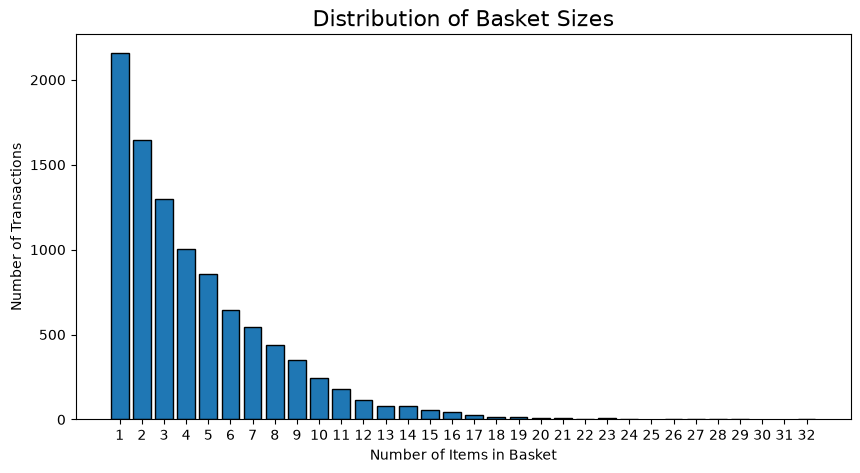

In [11]:
basket_size = df['Item(s)'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(basket_size.index, basket_size.values, edgecolor='black')
plt.xticks(range(1, 33))
plt.title("Distribution of Basket Sizes", fontsize=16)
plt.xlabel("Number of Items in Basket")
plt.ylabel("Number of Transactions")
plt.show()

In [12]:
# Select all product columns (Item 1 to Item 32)
item_columns = df.iloc[:, 1:]

# Convert all product values into a one-dimensional NumPy array
all_items = item_columns.values.ravel()

# Convert the NumPy array into a Pandas Series
all_items = pd.Series(all_items)

# Remove missing (NaN) values
all_items = all_items.dropna()

# Count the frequency of each product
product_counts = all_items.value_counts()

# Display the top 10 most frequently purchased products
product_counts.head(10)

whole milk          2513
other vegetables    1903
rolls/buns          1809
soda                1715
yogurt              1372
bottled water       1087
root vegetables     1072
tropical fruit      1032
shopping bags        969
sausage              924
Name: count, dtype: int64

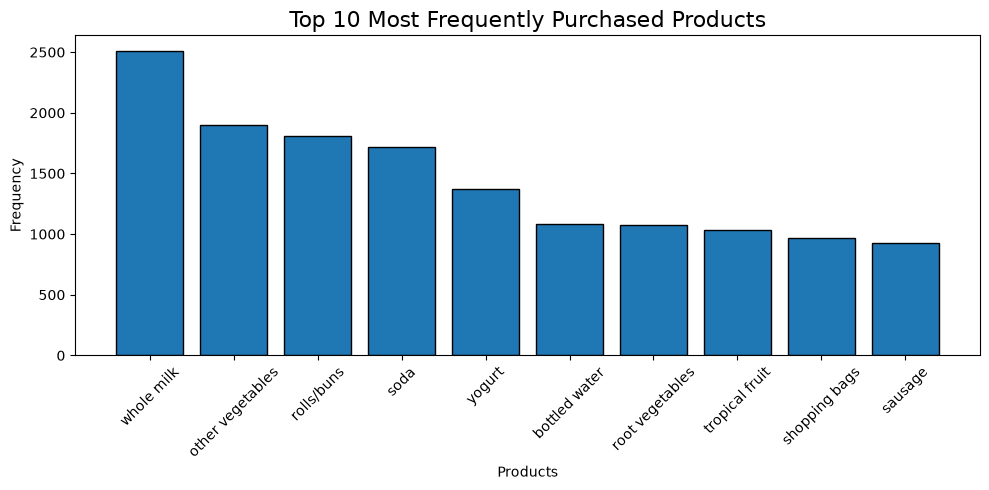

In [13]:
top10_products = product_counts.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10_products.index, top10_products.values, edgecolor='black')
plt.title("Top 10 Most Frequently Purchased Products", fontsize=16)
plt.xlabel("Products")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Preprocessing
The csv file was read transaction by transaction and each transaction was saved as a list. A mapping was created from the unique items in the dataset to integers so that each item corresponded to a unique integer. The entire data was mapped to integers to reduce the storage and computational requirement. A reverse mapping was created from the integers to the item, so that the item names could be written in the final output file.

In [14]:
transactions = []
for _, row in df.iloc[:, 1:].iterrows():
    transaction = row.dropna().tolist()
    transactions.append(transaction)
transactions[:5]

[['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups'],
 ['tropical fruit', 'yogurt', 'coffee'],
 ['whole milk'],
 ['pip fruit', 'yogurt', 'cream cheese', 'meat spreads'],
 ['other vegetables',
  'whole milk',
  'condensed milk',
  'long life bakery product']]

## Apriori Algorithm

In [15]:
apriori_times = []

for _ in range(5):
    start_time = time.time()

    itemsets, rules = apriori(
        transactions,
        min_support=0.02,
        min_confidence=0.3
    )

    end_time = time.time()

    apriori_times.append(end_time - start_time)

apriori_time = sum(apriori_times) / len(apriori_times)

print(f"Average Apriori Execution Time: {apriori_time:.4f} seconds")

Average Apriori Execution Time: 0.0975 seconds


In [16]:
type(itemsets)

dict

In [17]:
type(rules)

list

In [18]:
len(itemsets)

3

In [19]:
len(rules)

37

### Creating a Frequent Itemsets Table

The frequent itemsets returned by the Apriori algorithm are stored as a dictionary. For better readability and analysis, they are converted into a Pandas DataFrame containing the itemset, itemset size, count, and support.

In [20]:
# Total number of transactions
total_transactions = len(transactions)

# Empty list to store frequent itemsets
itemsets_data = []

# Convert dictionary into a list
for size, sets in itemsets.items():

    for itemset, count in sets.items():

        itemsets_data.append({
            "Itemset": ", ".join(itemset),
            "Itemset Size": size,
            "Count": count,
            "Support": round(count / total_transactions, 4)
        })

# Convert into DataFrame
itemsets_df = pd.DataFrame(itemsets_data)

# Display first 10 rows
itemsets_df.head(10)

,Itemset,Itemset Size,Count,Support
0,citrus fruit,1,814,0.0828
1,margarine,1,576,0.0586
2,tropical fruit,1,1032,0.1049
3,yogurt,1,1372,0.1395
4,coffee,1,571,0.0581
5,whole milk,1,2513,0.2555
6,pip fruit,1,744,0.0756
7,cream cheese,1,390,0.0397
8,other vegetables,1,1903,0.1935
9,long life bakery product,1,368,0.0374


In [21]:
top_itemsets = itemsets_df.sort_values(
    by="Support",
    ascending=False
)

top_itemsets.head(10)

,Itemset,Itemset Size,Count,Support
5,whole milk,1,2513,0.2555
8,other vegetables,1,1903,0.1935
11,rolls/buns,1,1809,0.1839
20,soda,1,1715,0.1744
3,yogurt,1,1372,0.1395
15,bottled water,1,1087,0.1105
28,root vegetables,1,1072,0.1090
2,tropical fruit,1,1032,0.1049
35,shopping bags,1,969,0.0985
33,sausage,1,924,0.0940


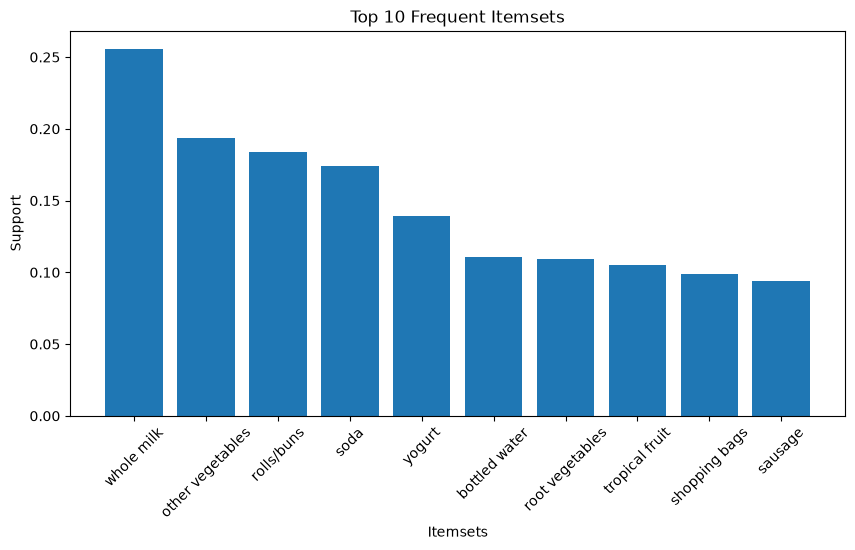

In [22]:
top10 = top_itemsets.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["Itemset"],
    top10["Support"]
)

plt.title("Top 10 Frequent Itemsets")
plt.xlabel("Itemsets")
plt.ylabel("Support")

plt.xticks(rotation=45)

plt.show()

## FP-Growth Algorithm

In [23]:
fp_times = []

for _ in range(5):
    start_time = time.time()

    patterns = pyfpgrowth.find_frequent_patterns(
        transactions,
        200
    )

    end_time = time.time()

    fp_times.append(end_time - start_time)

fp_time = sum(fp_times) / len(fp_times)

print(f"Average FP-Growth Execution Time: {fp_time:.4f} seconds")

Average FP-Growth Execution Time: 0.4319 seconds


In [24]:
type(patterns)

dict

In [25]:
len(patterns)

106

In [26]:
list(patterns.items())[:10]

[(('chewing gum',), 207),
 (('grapes',), 220),
 (('cat food',), 229),
 (('hard cheese',), 241),
 (('sliced cheese',), 241),
 (('ice cream',), 246),
 (('meat',), 254),
 (('beverages',), 256),
 (('ham',), 256),
 (('specialty bar',), 269)]

In [27]:
patterns_data = []

for itemset, count in patterns.items():
    patterns_data.append({
        "Itemset": ", ".join(itemset),
        "Itemset Size": len(itemset),
        "Count": count,
        "Support": round(count / len(transactions), 4)
    })

patterns_df = pd.DataFrame(patterns_data)

patterns_df.head(10)

,Itemset,Itemset Size,Count,Support
0,chewing gum,1,207,0.0210
1,grapes,1,220,0.0224
2,cat food,1,229,0.0233
3,hard cheese,1,241,0.0245
4,sliced cheese,1,241,0.0245
5,ice cream,1,246,0.0250
6,meat,1,254,0.0258
7,beverages,1,256,0.0260
8,ham,1,256,0.0260
9,specialty bar,1,269,0.0274


### Top Frequent Itemsets (FP-Growth)

In [28]:
patterns_df = patterns_df.sort_values(by="Support", ascending=False)

patterns_df.head(10)

,Itemset,Itemset Size,Count,Support
105,whole milk,1,2513,0.2555
103,other vegetables,1,1903,0.1935
61,bottled beer,1,792,0.0805
59,newspapers,1,785,0.0798
58,canned beer,1,764,0.0777
104,"other vegetables, whole milk",2,736,0.0748
48,brown bread,1,638,0.0649
44,frankfurter,1,580,0.0590
42,margarine,1,576,0.0586
41,coffee,1,571,0.0581


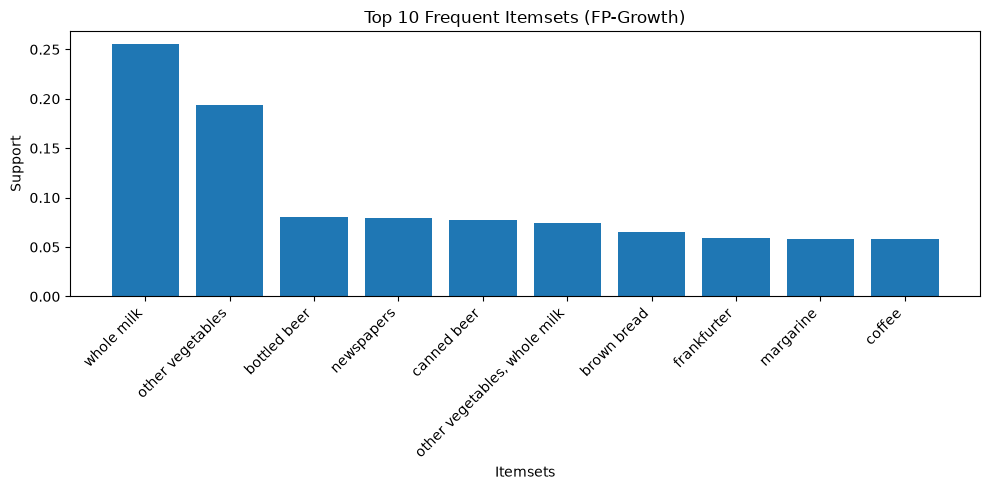

In [29]:
top10_fp = patterns_df.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10_fp["Itemset"], top10_fp["Support"])

plt.title("Top 10 Frequent Itemsets (FP-Growth)")
plt.xlabel("Itemsets")
plt.ylabel("Support")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Execution Time Comparison

In [30]:
comparison_df = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Average Execution Time (seconds)": [apriori_time, fp_time],
    "Frequent Itemsets": [len(itemsets_df), len(patterns_df)]
})

comparison_df

,Algorithm,Average Execution Time (seconds),Frequent Itemsets
0,Apriori,0.097461,122
1,FP-Growth,0.431890,106


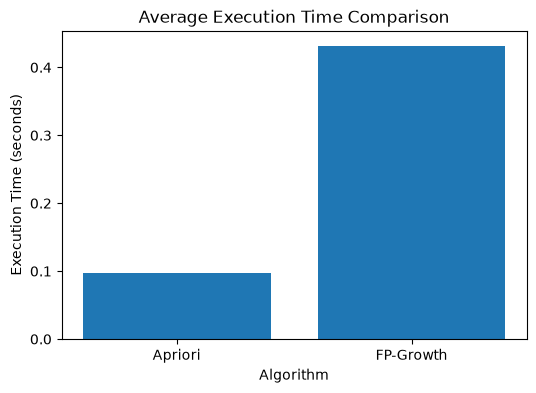

In [31]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Average Execution Time (seconds)"]
)

plt.title("Average Execution Time Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Execution Time (seconds)")

plt.show()

## Association Rule Mining

Association rule mining is used to discover relationships between products that are frequently purchased together. These rules help businesses identify cross-selling opportunities and improve product recommendations.

### Association Rules using Apriori

In [32]:
type(rules)

list

In [33]:
len(rules)

37

In [34]:
rules[:5]

[{beef} -> {whole milk},
 {bottled water} -> {whole milk},
 {brown bread} -> {whole milk},
 {butter} -> {other vegetables},
 {butter} -> {whole milk}]

In [35]:
rules_data = []

for rule in rules:
    rules_data.append({
        "Antecedent": ", ".join(rule.lhs),
        "Consequent": ", ".join(rule.rhs),
        "Support": round(rule.support, 4),
        "Confidence": round(rule.confidence, 4),
        "Lift": round(rule.lift, 4),
        "Conviction": round(rule.conviction, 4)
    })

rules_df = pd.DataFrame(rules_data)

rules_df.head(10)

,Antecedent,Consequent,Support,Confidence,Lift,Conviction
0,beef,whole milk,0.0213,0.4050,1.5852,1.2513
1,bottled water,whole milk,0.0344,0.3109,1.2169,1.0804
2,brown bread,whole milk,0.0252,0.3887,1.5213,1.2179
3,butter,other vegetables,0.0200,0.3615,1.8681,1.2631
4,butter,whole milk,0.0276,0.4972,1.9461,1.4808
5,citrus fruit,other vegetables,0.0289,0.3489,1.8031,1.2387
6,citrus fruit,whole milk,0.0305,0.3686,1.4424,1.1790
7,curd,whole milk,0.0261,0.4905,1.9195,1.4611
8,domestic eggs,other vegetables,0.0223,0.3510,1.8138,1.2426
9,domestic eggs,whole milk,0.0300,0.4728,1.8502,1.4120


### Top Association Rules by Confidence

In [36]:
top_confidence = rules_df.sort_values(
    by="Confidence",
    ascending=False
)

top_confidence.head(10)

,Antecedent,Consequent,Support,Confidence,Lift,Conviction
36,"other vegetables, yogurt",whole milk,0.0223,0.5129,2.0072,1.5283
4,butter,whole milk,0.0276,0.4972,1.9461,1.4808
7,curd,whole milk,0.0261,0.4905,1.9195,1.4611
34,"other vegetables, root vegetables",whole milk,0.0232,0.4893,1.9148,1.4577
32,"root vegetables, whole milk",other vegetables,0.0232,0.4740,2.4498,1.5333
9,domestic eggs,whole milk,0.0300,0.4728,1.8502,1.4120
30,whipped/sour cream,whole milk,0.0322,0.4496,1.7598,1.3527
27,root vegetables,whole milk,0.0489,0.4487,1.7560,1.3504
17,root vegetables,other vegetables,0.0474,0.4347,2.2466,1.4267
11,frozen vegetables,whole milk,0.0204,0.4249,1.6631,1.2946


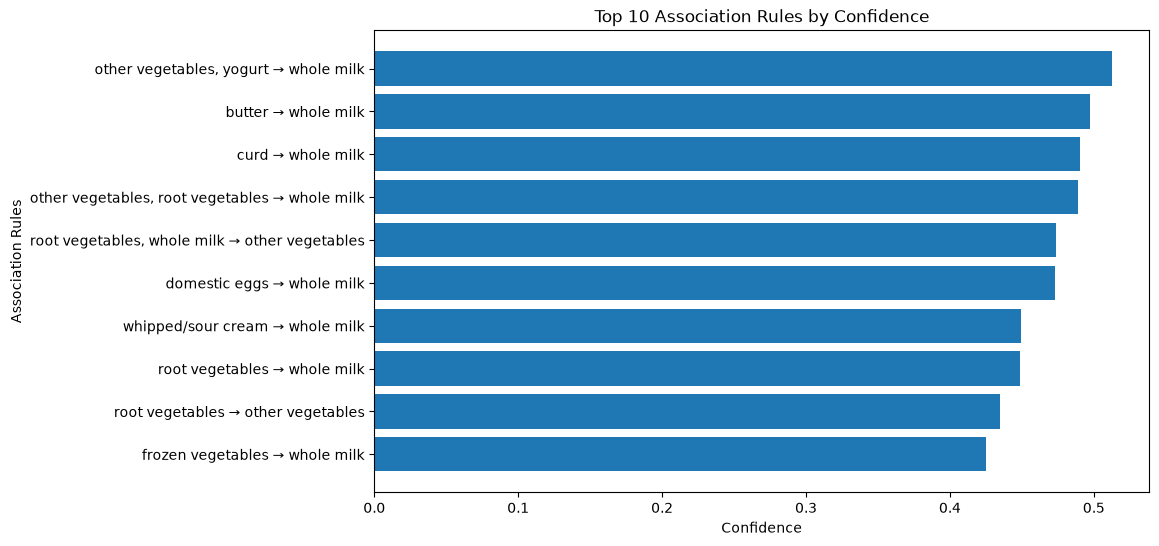

In [37]:
plt.figure(figsize=(10,6))

plt.barh(
    top_confidence.head(10)["Antecedent"] + " → " + top_confidence.head(10)["Consequent"],
    top_confidence.head(10)["Confidence"]
)

plt.title("Top 10 Association Rules by Confidence")
plt.xlabel("Confidence")
plt.ylabel("Association Rules")

plt.gca().invert_yaxis()

plt.show()

### Top Association Rules by Lift

In [38]:
top_lift = rules_df.sort_values(
    by="Lift",
    ascending=False
)

top_lift.head(10)

,Antecedent,Consequent,Support,Confidence,Lift,Conviction
33,"other vegetables, whole milk",root vegetables,0.0232,0.3098,2.8421,1.2909
32,"root vegetables, whole milk",other vegetables,0.0232,0.4740,2.4498,1.5333
17,root vegetables,other vegetables,0.0474,0.4347,2.2466,1.4267
19,whipped/sour cream,other vegetables,0.0289,0.4028,2.0819,1.3506
35,"whole milk, yogurt",other vegetables,0.0223,0.3975,2.0541,1.3385
36,"other vegetables, yogurt",whole milk,0.0223,0.5129,2.0072,1.5283
4,butter,whole milk,0.0276,0.4972,1.9461,1.4808
16,pork,other vegetables,0.0217,0.3757,1.9415,1.2918
7,curd,whole milk,0.0261,0.4905,1.9195,1.4611
34,"other vegetables, root vegetables",whole milk,0.0232,0.4893,1.9148,1.4577


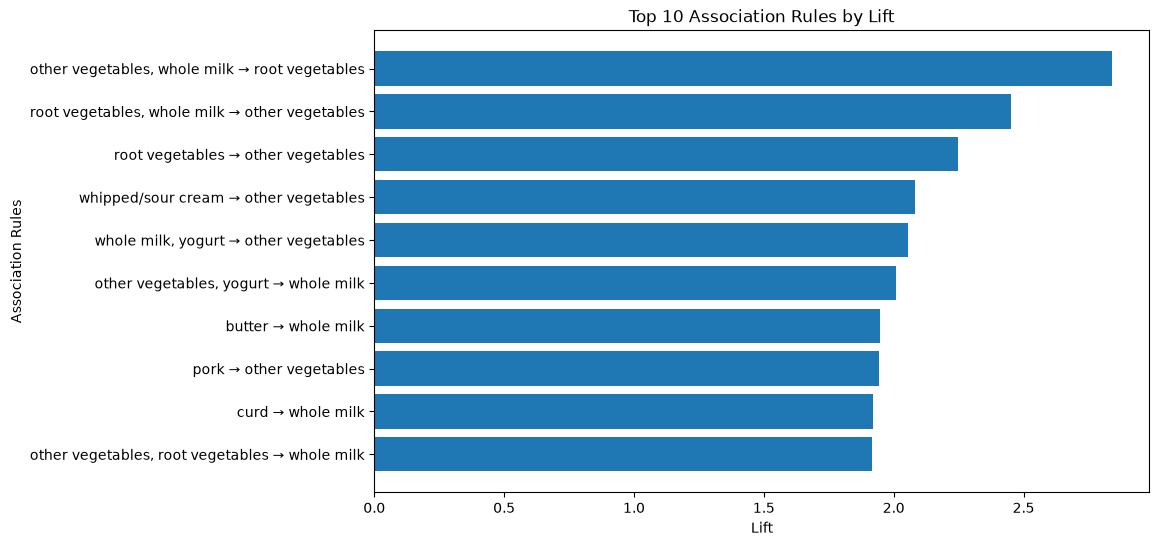

In [39]:
plt.figure(figsize=(10,6))

plt.barh(
    top_lift.head(10)["Antecedent"] + " → " + top_lift.head(10)["Consequent"],
    top_lift.head(10)["Lift"]
)

plt.title("Top 10 Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Association Rules")

plt.gca().invert_yaxis()

plt.show()

### Strong Association Rules (Apriori)

In [40]:
strong_rules = rules_df[
    (rules_df["Confidence"] >= 0.30) &
    (rules_df["Lift"] > 1)
]

In [41]:
len(strong_rules)

37

In [42]:
strong_rules.head(10)

,Antecedent,Consequent,Support,Confidence,Lift,Conviction
0,beef,whole milk,0.0213,0.4050,1.5852,1.2513
1,bottled water,whole milk,0.0344,0.3109,1.2169,1.0804
2,brown bread,whole milk,0.0252,0.3887,1.5213,1.2179
3,butter,other vegetables,0.0200,0.3615,1.8681,1.2631
4,butter,whole milk,0.0276,0.4972,1.9461,1.4808
5,citrus fruit,other vegetables,0.0289,0.3489,1.8031,1.2387
6,citrus fruit,whole milk,0.0305,0.3686,1.4424,1.1790
7,curd,whole milk,0.0261,0.4905,1.9195,1.4611
8,domestic eggs,other vegetables,0.0223,0.3510,1.8138,1.2426
9,domestic eggs,whole milk,0.0300,0.4728,1.8502,1.4120


### Top 10 Strong Rules by Confidence

In [43]:
strong_confidence = strong_rules.sort_values(
    by="Confidence",
    ascending=False
)

strong_confidence.head(10)

,Antecedent,Consequent,Support,Confidence,Lift,Conviction
36,"other vegetables, yogurt",whole milk,0.0223,0.5129,2.0072,1.5283
4,butter,whole milk,0.0276,0.4972,1.9461,1.4808
7,curd,whole milk,0.0261,0.4905,1.9195,1.4611
34,"other vegetables, root vegetables",whole milk,0.0232,0.4893,1.9148,1.4577
32,"root vegetables, whole milk",other vegetables,0.0232,0.4740,2.4498,1.5333
9,domestic eggs,whole milk,0.0300,0.4728,1.8502,1.4120
30,whipped/sour cream,whole milk,0.0322,0.4496,1.7598,1.3527
27,root vegetables,whole milk,0.0489,0.4487,1.7560,1.3504
17,root vegetables,other vegetables,0.0474,0.4347,2.2466,1.4267
11,frozen vegetables,whole milk,0.0204,0.4249,1.6631,1.2946


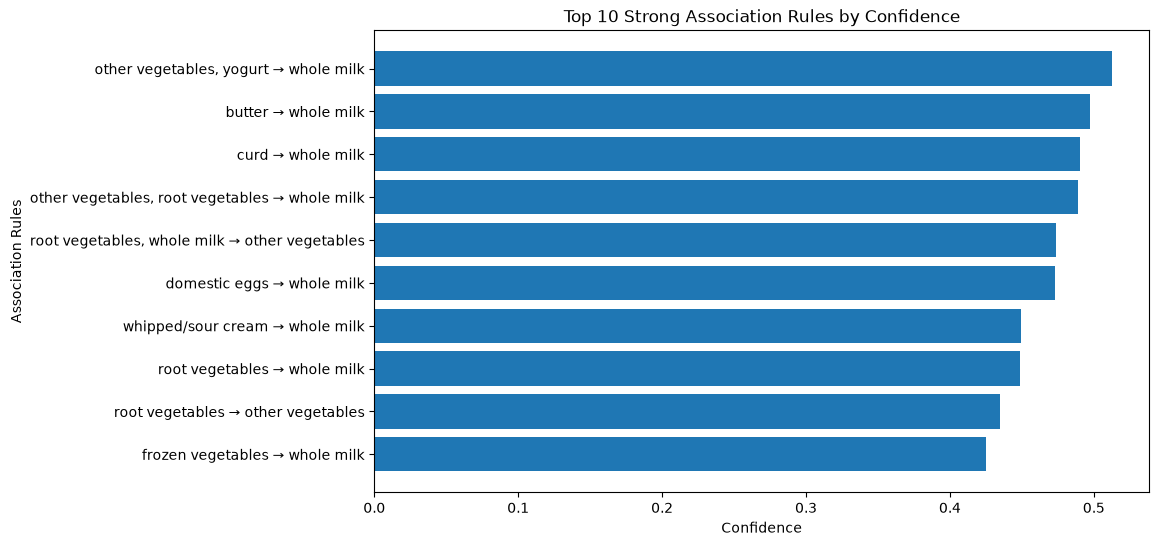

In [44]:
plt.figure(figsize=(10,6))

plt.barh(
    strong_confidence.head(10)["Antecedent"] + " → " + strong_confidence.head(10)["Consequent"],
    strong_confidence.head(10)["Confidence"]
)

plt.title("Top 10 Strong Association Rules by Confidence")
plt.xlabel("Confidence")
plt.ylabel("Association Rules")

plt.gca().invert_yaxis()

plt.show()

### Top 10 Strong Rules by Lift

In [45]:
strong_lift = strong_rules.sort_values(
    by="Lift",
    ascending=False
)

strong_lift.head(10)

,Antecedent,Consequent,Support,Confidence,Lift,Conviction
33,"other vegetables, whole milk",root vegetables,0.0232,0.3098,2.8421,1.2909
32,"root vegetables, whole milk",other vegetables,0.0232,0.4740,2.4498,1.5333
17,root vegetables,other vegetables,0.0474,0.4347,2.2466,1.4267
19,whipped/sour cream,other vegetables,0.0289,0.4028,2.0819,1.3506
35,"whole milk, yogurt",other vegetables,0.0223,0.3975,2.0541,1.3385
36,"other vegetables, yogurt",whole milk,0.0223,0.5129,2.0072,1.5283
4,butter,whole milk,0.0276,0.4972,1.9461,1.4808
16,pork,other vegetables,0.0217,0.3757,1.9415,1.2918
7,curd,whole milk,0.0261,0.4905,1.9195,1.4611
34,"other vegetables, root vegetables",whole milk,0.0232,0.4893,1.9148,1.4577


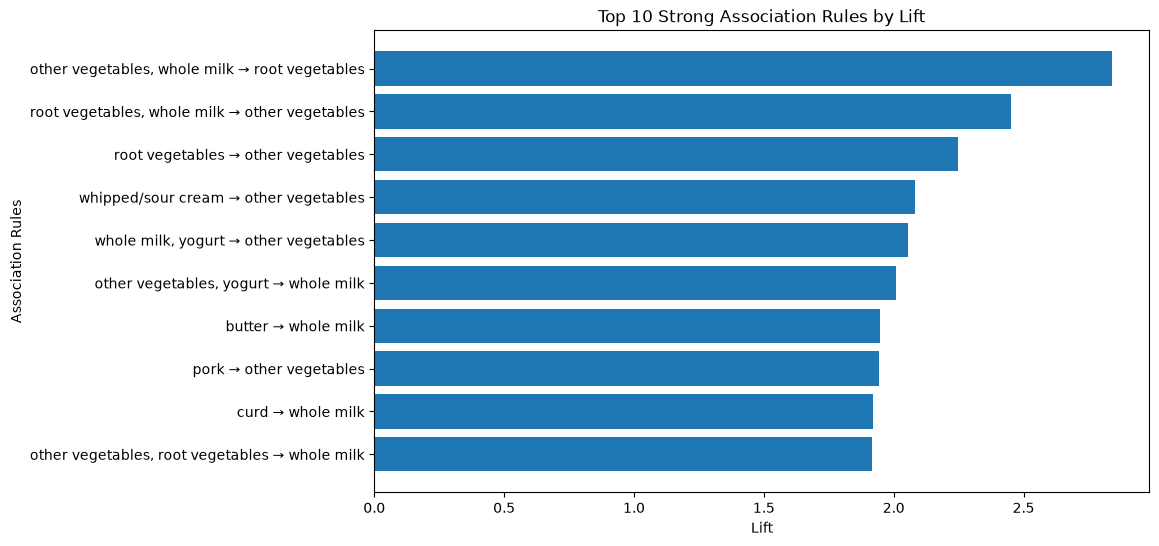

In [46]:
plt.figure(figsize=(10,6))

plt.barh(
    strong_lift.head(10)["Antecedent"] + " → " + strong_lift.head(10)["Consequent"],
    strong_lift.head(10)["Lift"]
)

plt.title("Top 10 Strong Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Association Rules")

plt.gca().invert_yaxis()

plt.show()

### FP-Growth Association Rules

In [47]:
fp_rules = pyfpgrowth.generate_association_rules(patterns, 0.3)

In [48]:
type(fp_rules)

dict

In [49]:
len(fp_rules)

14

In [50]:
list(fp_rules.items())[:10]

[(('frozen vegetables',), (('whole milk',), 0.4249471458773784)),
 (('beef',), (('whole milk',), 0.4050387596899225)),
 (('curd',), (('whole milk',), 0.4904580152671756)),
 (('butter',), (('whole milk',), 0.4972477064220184)),
 (('margarine',), (('whole milk',), 0.4131944444444444)),
 (('frankfurter',), (('whole milk',), 0.3482758620689655)),
 (('brown bread',), (('whole milk',), 0.3887147335423197)),
 (('newspapers',), (('whole milk',), 0.34267515923566877)),
 (('other vegetables', 'root vegetables'),
  (('whole milk',), 0.4892703862660944)),
 (('other vegetables', 'whole milk'),
  (('root vegetables',), 0.30978260869565216))]

In [51]:
fp_rules_data = []

for antecedent, (consequent, confidence) in fp_rules.items():

    fp_rules_data.append({
        "Antecedent": ", ".join(antecedent),
        "Consequent": ", ".join(consequent),
        "Confidence": round(confidence, 4)
    })

fp_rules_df = pd.DataFrame(fp_rules_data)

fp_rules_df

,Antecedent,Consequent,Confidence
0,frozen vegetables,whole milk,0.4249
1,beef,whole milk,0.4050
2,curd,whole milk,0.4905
3,butter,whole milk,0.4972
4,margarine,whole milk,0.4132
5,frankfurter,whole milk,0.3483
6,brown bread,whole milk,0.3887
7,newspapers,whole milk,0.3427
8,"other vegetables, root vegetables",whole milk,0.4893
9,"other vegetables, whole milk",root vegetables,0.3098


### Top Association Rules by Confidence (FP-Growth)

In [52]:
fp_top_confidence = fp_rules_df.sort_values(
    by="Confidence",
    ascending=False
)

fp_top_confidence.head(10)

,Antecedent,Consequent,Confidence
11,"other vegetables, yogurt",whole milk,0.5129
3,butter,whole milk,0.4972
2,curd,whole milk,0.4905
8,"other vegetables, root vegetables",whole milk,0.4893
10,"root vegetables, whole milk",other vegetables,0.4740
0,frozen vegetables,whole milk,0.4249
4,margarine,whole milk,0.4132
1,beef,whole milk,0.4050
12,"whole milk, yogurt",other vegetables,0.3975
6,brown bread,whole milk,0.3887


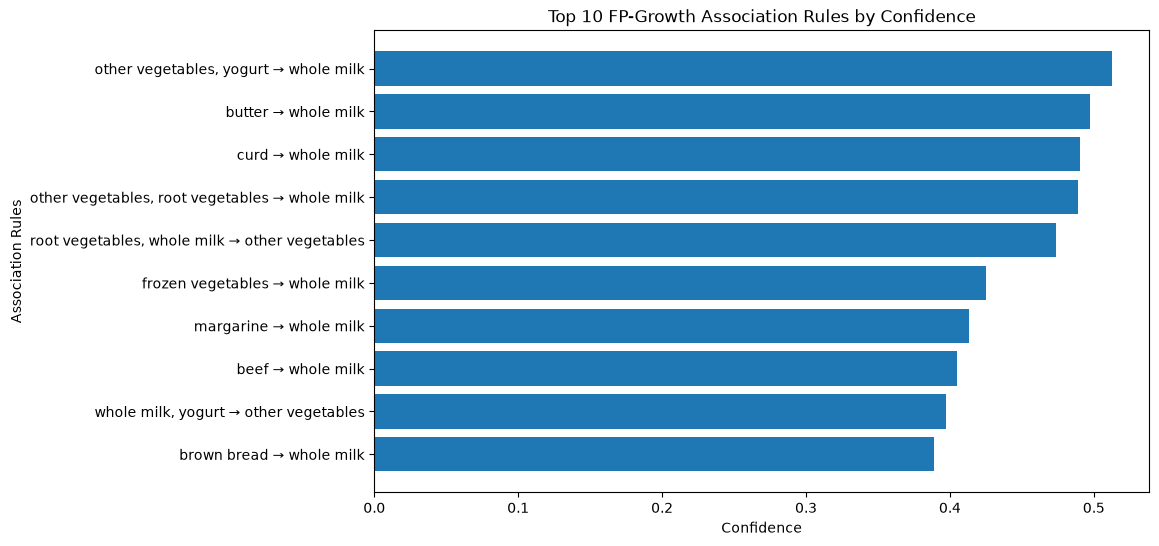

In [53]:
plt.figure(figsize=(10, 6))

labels = (
    fp_top_confidence.head(10)["Antecedent"]
    + " → "
    + fp_top_confidence.head(10)["Consequent"]
)

plt.barh(
    labels,
    fp_top_confidence.head(10)["Confidence"]
)

plt.xlabel("Confidence")
plt.ylabel("Association Rules")
plt.title("Top 10 FP-Growth Association Rules by Confidence")

plt.gca().invert_yaxis()

plt.show()

## Apriori vs FP-Growth Comparison

In [54]:
comparison_df = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Frequent Itemsets": [len(itemsets_df), len(patterns_df)],
    "Association Rules": [len(rules_df), len(fp_rules_df)],
    "Execution Time (seconds)": [
        round(apriori_time, 4),
        round(fp_time, 4)
    ]
})

comparison_df

,Algorithm,Frequent Itemsets,Association Rules,Execution Time (seconds)
0,Apriori,122,37,0.0975
1,FP-Growth,106,14,0.4319


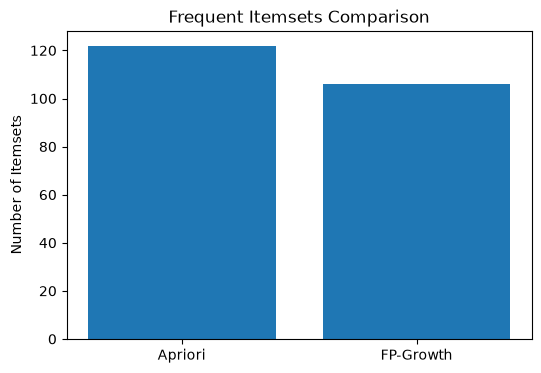

In [55]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Frequent Itemsets"]
)

plt.title("Frequent Itemsets Comparison")
plt.ylabel("Number of Itemsets")

plt.show()

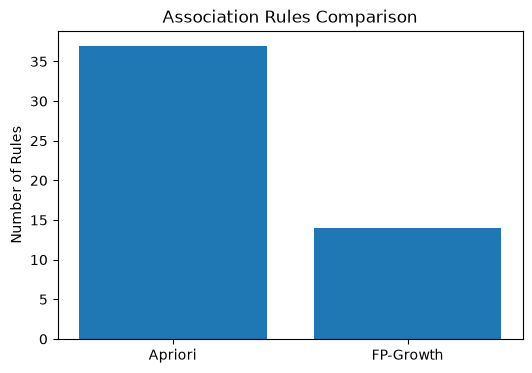

In [56]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Association Rules"]
)

plt.title("Association Rules Comparison")
plt.ylabel("Number of Rules")

plt.show()

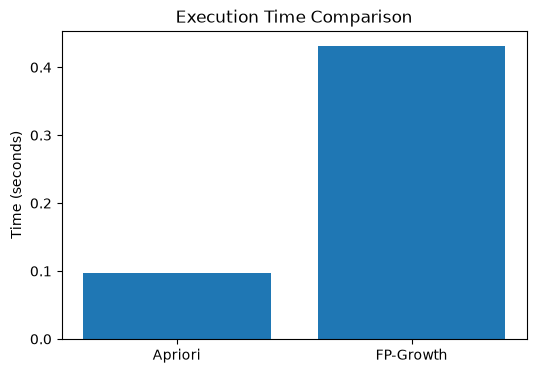

In [57]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Execution Time (seconds)"]
)

plt.title("Execution Time Comparison")
plt.ylabel("Time (seconds)")

plt.show()

## Business Insights and Recommendations

### Key Business Insights

Based on the association rule mining results, the following business insights can be drawn:

- Frequently purchased products can be identified using association rule mining.
- Products with high confidence and lift values indicate strong purchasing relationships.
- These relationships can be used to improve customer recommendations and increase sales.

### Product Recommendations

Customers who purchase certain products are likely to buy related products together. These association rules can be used to build recommendation systems for supermarkets and online grocery stores.

### Cross-Selling Opportunities

Products that frequently appear together can be promoted through cross-selling strategies. When a customer purchases one product, the associated product can be recommended to increase the average basket value.

### Store Layout Optimization

Frequently purchased product combinations should be placed closer together in the store. This improves customer convenience and can increase overall sales.

### Promotional Bundles

Products with strong association rules can be offered as discounted bundles or promotional packages to encourage customers to purchase multiple items together.

### Inventory Management

Understanding purchasing patterns helps retailers maintain sufficient stock levels for products that are commonly bought together, reducing the risk of stock shortages.

## Conclusion

In this project, Market Basket Analysis was performed using the Apriori and FP-Growth algorithms to discover frequent itemsets and association rules from the grocery transactions dataset.

The analysis identified product combinations that are frequently purchased together, which can help retailers improve product recommendations, cross-selling strategies, promotional campaigns, and store layout planning.

Both algorithms successfully discovered meaningful association rules. In this experiment, the Apriori algorithm generated more frequent itemsets and association rules and also achieved a lower execution time than the FP-Growth algorithm. However, this comparison is based on the current dataset, selected parameters, and the libraries used. On larger datasets, FP-Growth is generally considered more efficient because it avoids generating a large number of candidate itemsets.

Overall, Market Basket Analysis provides valuable insights into customer purchasing behavior and supports data-driven business decisions in the retail industry.

